# Purpose:
- Calculate coding score across sessions
- Using no pupil GLM (v00), Thyme, natural images sessions

In [120]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
from comb.behavior_ophys_dataset import BehaviorOphysDataset, BehaviorMultiplaneOphysDataset
from comb.behavior_session_dataset import BehaviorSessionDataset
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json
from tqdm import tqdm
from matplotlib import pyplot as plt

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils
import load_data
import design_matrix_tools as dmtools
import kernel_tools as ktools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
def calculate_coding_score(var_explained_xr, models=None):
    model_labels = var_explained_xr.model
    if models is None:
        models = [m for m in model_labels if 
                  m != 'Full' and
                  not m.startswith('single-')]
    assert np.all([m in model_labels for m in models])
    assert 'Full' in model_labels
    return var_explained_xr.sel(model='Full') - var_explained_xr.sel(model=models)

In [30]:
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'


In [59]:
session_names = [rp.split('/')[-1] for rp in raw_paths]
abbr_session_names = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'abbr_session_name': abbr_session_names,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('abbr_session_name', drop=True, inplace=True)

In [60]:
session_info_df

,session_name,session_ind,session_type
abbr_session_name,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [86]:
matched_unique_cell_name

cell_roi_id
VISp_7_0000    Series([], Name: unique_cell_name, dtype: object)
VISp_7_0001    Series([], Name: unique_cell_name, dtype: object)
VISp_7_0002    Series([], Name: unique_cell_name, dtype: object)
VISp_7_0003    Series([], Name: unique_cell_name, dtype: object)
VISp_7_0004    Series([], Name: unique_cell_name, dtype: object)
                                     ...                        
VISp_6_0043    Series([], Name: unique_cell_name, dtype: object)
VISp_6_0044    Series([], Name: unique_cell_name, dtype: object)
VISp_6_0045    Series([], Name: unique_cell_name, dtype: object)
VISp_6_0046    Series([], Name: unique_cell_name, dtype: object)
VISp_6_0047    Series([], Name: unique_cell_name, dtype: object)
Length: 635, dtype: object

In [162]:
matched_roi_id

['VISp_0_0000',
 'VISp_0_0001',
 'VISp_0_0002',
 'VISp_0_0003',
 'VISp_0_0004',
 'VISp_0_0005',
 'VISp_0_0006',
 'VISp_0_0007',
 'VISp_0_0009',
 'VISp_0_0010',
 'VISp_0_0011',
 'VISp_0_0012',
 'VISp_0_0013',
 'VISp_0_0015',
 'VISp_0_0016',
 'VISp_0_0017',
 'VISp_0_0018',
 'VISp_0_0019',
 'VISp_0_0020',
 'VISp_0_0021',
 'VISp_0_0022',
 'VISp_0_0023',
 'VISp_0_0025',
 'VISp_0_0026',
 'VISp_0_0027',
 'VISp_0_0028',
 'VISp_0_0029',
 'VISp_0_0030',
 'VISp_0_0031',
 'VISp_0_0032',
 'VISp_0_0033',
 'VISp_0_0034',
 'VISp_0_0035',
 'VISp_0_0036',
 'VISp_0_0037',
 'VISp_0_0038',
 'VISp_0_0039',
 'VISp_0_0040',
 'VISp_0_0041',
 'VISp_0_0042',
 'VISp_0_0044',
 'VISp_0_0045',
 'VISp_0_0046',
 'VISp_0_0047',
 'VISp_0_0048',
 'VISp_0_0049',
 'VISp_0_0050',
 'VISp_0_0051',
 'VISp_0_0052',
 'VISp_0_0053',
 'VISp_0_0054',
 'VISp_0_0055',
 'VISp_0_0056',
 'VISp_0_0057',
 'VISp_0_0058',
 'VISp_0_0059',
 'VISp_0_0060',
 'VISp_0_0061',
 'VISp_0_0062',
 'VISp_0_0063',
 'VISp_0_0064',
 'VISp_0_0065',
 'VISp_0

In [163]:
images_coding_score_xr.cell_roi_id.values

array(['VISp_7_0000', 'VISp_7_0001', 'VISp_7_0002', 'VISp_7_0003',
       'VISp_7_0004', 'VISp_7_0005', 'VISp_7_0006', 'VISp_7_0007',
       'VISp_7_0008', 'VISp_7_0009', 'VISp_7_0010', 'VISp_7_0011',
       'VISp_7_0012', 'VISp_7_0013', 'VISp_7_0014', 'VISp_7_0015',
       'VISp_7_0016', 'VISp_7_0017', 'VISp_7_0018', 'VISp_7_0019',
       'VISp_7_0020', 'VISp_7_0021', 'VISp_7_0022', 'VISp_7_0023',
       'VISp_7_0024', 'VISp_7_0025', 'VISp_7_0026', 'VISp_7_0027',
       'VISp_7_0028', 'VISp_7_0029', 'VISp_7_0030', 'VISp_7_0031',
       'VISp_7_0032', 'VISp_7_0033', 'VISp_7_0034', 'VISp_7_0035',
       'VISp_7_0036', 'VISp_7_0037', 'VISp_7_0038', 'VISp_7_0039',
       'VISp_7_0040', 'VISp_7_0041', 'VISp_7_0042', 'VISp_7_0043',
       'VISp_7_0044', 'VISp_7_0045', 'VISp_7_0046', 'VISp_7_0048',
       'VISp_7_0049', 'VISp_7_0050', 'VISp_7_0051', 'VISp_7_0052',
       'VISp_7_0053', 'VISp_7_0054', 'VISp_7_0055', 'VISp_7_0056',
       'VISp_7_0057', 'VISp_7_0058', 'VISp_7_0059', 'VISp_7_00

In [165]:
set(matched_roi_id) - set(images_coding_score_xr.cell_roi_id.values)

{'VISp_0_0005',
 'VISp_0_0060',
 'VISp_1_0021',
 'VISp_2_0007',
 'VISp_2_0048',
 'VISp_3_0053',
 'VISp_4_0038',
 'VISp_5_0100',
 'VISp_7_0047'}

In [168]:
session_roi_cat_df.query('fov_name=="VISp_0" and roi_session_index==5')

,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key,roi_name,session_ind,unique_cell_name
214,214,VISp_0,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,5,90,8747aad9-0279-47ea-add4-5557f6749176,0.905589,1.0,True,736963_2024-07-24,736963_2024-07-24_VISp_0_0005,0,VISp_0_0090


In [161]:
from tqdm import tqdm
images_coding_score_list = []
session_names = []
session_inds = np.arange(11)

for session_ind in tqdm(range(11)):
    session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
    session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
    session_names.append(session_ind)
    glm_path = Path(glm_dir) / f'glm_results_v00_{session_name}_events.npy'
    glm_results = np.load(glm_path, allow_pickle=True).item()
    images_coding_score_xr = calculate_coding_score(
        glm_results['var_ratio_mean_model'],
        models=['all-images']).expand_dims(
            session_key=[session_key]
        )

    matched_unique_cell_name = []
    session_roi_cat_df = roicat_df.query(f'session_ind=={session_ind}')
    matched_df = session_roi_cat_df.query('matched==True')
    matched_roi_id = ['_'.join(rn.split('_')[2:]) for rn in matched_df.roi_name.values]
    images_coding_score_xr = images_coding_score_xr.sel(cell_roi_id=matched_roi_id)
    
    unique_cell_names = []
    for cell_roi_id in images_coding_score_xr.cell_roi_id.values:
        roi_name = f'{session_key}_{cell_roi_id}'
        unique_cell_names.append(session_roi_cat_df.query(f'roi_name=="{roi_name}"').unique_cell_name.values[0])
    
    images_coding_score_xr = images_coding_score_xr.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
    images_coding_score_xr = images_coding_score_xr.swap_dims({"cell_roi_id": "unique_cell_name"})
    
    images_coding_score_list.append(images_coding_score_xr)



  0%|          | 0/11 [00:00<?, ?it/s]

KeyError: "not all values found in index 'cell_roi_id'"

In [158]:
include_cell_names

[<xarray.DataArray 'unique_cell_name' ()> Size: 44B
 array('VISp_7_-001', dtype='<U11')
 Coordinates:
     cell_roi_id       <U11 44B 'VISp_7_0000'
     unique_cell_name  <U11 44B 'VISp_7_-001',
 <xarray.DataArray 'unique_cell_name' ()> Size: 44B
 array('VISp_7_0037', dtype='<U11')
 Coordinates:
     cell_roi_id       <U11 44B 'VISp_7_0001'
     unique_cell_name  <U11 44B 'VISp_7_0037',
 <xarray.DataArray 'unique_cell_name' ()> Size: 44B
 array('VISp_7_0131', dtype='<U11')
 Coordinates:
     cell_roi_id       <U11 44B 'VISp_7_0002'
     unique_cell_name  <U11 44B 'VISp_7_0131',
 <xarray.DataArray 'unique_cell_name' ()> Size: 44B
 array('VISp_7_0002', dtype='<U11')
 Coordinates:
     cell_roi_id       <U11 44B 'VISp_7_0003'
     unique_cell_name  <U11 44B 'VISp_7_0002',
 <xarray.DataArray 'unique_cell_name' ()> Size: 44B
 array('VISp_7_0000', dtype='<U11')
 Coordinates:
     cell_roi_id       <U11 44B 'VISp_7_0004'
     unique_cell_name  <U11 44B 'VISp_7_0000',
 <xarray.DataArray 'uniqu

In [157]:
len(np.unique(include_cell_names))

ValueError: setting an array element with a sequence

In [118]:
images_coding_score = xr.concat(images_coding_score_list, dim='unique_cell_name')

    

In [153]:
roicat_df.query('matched==False')

,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key,roi_name,session_ind,unique_cell_name
28,28,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,28,-1,01743c81-cba8-40ec-9f7d-2b419f3658f9,0.000000,1.0,False,736963_2024-08-09,736963_2024-08-09_VISp_0_0028,8,VISp_0_-001
40,40,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,40,-1,5d67ddd2-11fd-4b57-8256-b1b878b2622a,0.287596,1.0,False,736963_2024-08-09,736963_2024-08-09_VISp_0_0040,8,VISp_0_-001
49,49,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,49,-1,d618bf57-bf52-498a-a9f1-9f8b37d33e0a,-0.910482,1.0,False,736963_2024-08-09,736963_2024-08-09_VISp_0_0049,8,VISp_0_-001
67,67,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,67,-1,cba47028-4340-4920-8e07-d0f423caa804,-0.907177,1.0,False,736963_2024-08-09,736963_2024-08-09_VISp_0_0067,8,VISp_0_-001
69,69,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,69,-1,1d7683bb-c657-48c1-9720-c71ea3152e2c,0.000000,1.0,False,736963_2024-08-09,736963_2024-08-09_VISp_0_0069,8,VISp_0_-001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,1035,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,28,-1,61cc9d22-ff0d-4527-a34b-edf9163439be,0.000000,1.0,False,736963_2024-08-06,736963_2024-08-06_VISp_7_0028,6,VISp_7_-001
1084,1084,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,77,-1,87ea9f2d-918b-4811-a816-e0f854966057,0.000000,1.0,False,736963_2024-08-06,736963_2024-08-06_VISp_7_0077,6,VISp_7_-001
1096,1096,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,89,-1,5f33742e-b80f-4e9f-b12d-ac128f605605,0.000000,1.0,False,736963_2024-08-06,736963_2024-08-06_VISp_7_0089,6,VISp_7_-001
1099,1099,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,92,-1,a135154b-1b0f-43ee-b7f8-dfe867a6425b,-0.767656,1.0,False,736963_2024-08-06,736963_2024-08-06_VISp_7_0092,6,VISp_7_-001


In [145]:
num_matched_sessions = roicat_df.query('matched').groupby('unique_cell_name').size()
many_matched_ucn = num_matched_sessions.index.values[np.where(num_matched_sessions >= 9)[0]]

In [150]:
len(images_coding_score.unique_cell_name.values)

6997

In [152]:
len(np.unique(images_coding_score.unique_cell_name.values))

885

In [147]:
many_matched_ics = images_coding_score.sel(unique_cell_name=many_matched_ucn)

InvalidIndexError: Reindexing only valid with uniquely valued Index objects

In [131]:
images_coding_score

<xarray.DataArray (session_key: 11, unique_cell_name: 6997, model: 1)> Size: 616kB
array([[[0.00500988],
        [0.01423077],
        [0.04237   ],
        ...,
        [       nan],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
        [       nan],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
...
        ...,
        [       nan],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
        [       nan],
        [       nan],
        [       nan]],

       [[       nan],
        [       nan],
        [       nan],
        ...,
        [0.0046166 ],
        [0.01983177],
        [0.00847776]]])
Coordinates:
  * session_key       (session_key) object 88B '736963_2024-07-24' ... '73696...
  * model             (model) object 8B 'all-images'
  * unique_cell_name  (unique_cell_name) <U11 308kB 'VISp_7_-001' ... 'VISp_6...
    cell_roi_id       (unique_cell_name) object 56kB 'VISp_7_0000' ... 'VISp_...

In [130]:
ics_array = images_coding_score.values.squeeze().T


(array([   0,    0,    0, ..., 6996, 6996, 6996]),
 array([ 0,  1,  2, ...,  8,  9, 10]))

(-0.5, 6996.5, 10.5, 7007.5)

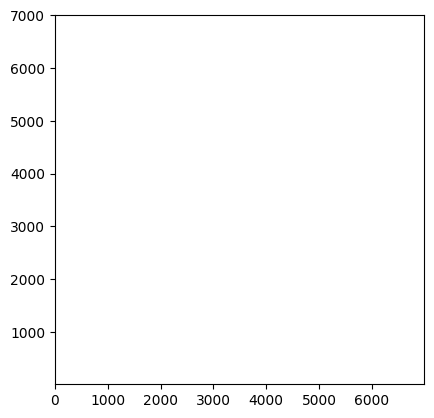

In [124]:
fig, ax = plt.subplots()
ax.imshow(images_coding_score)
ax.axis('square')

In [84]:
images_coding_score_list = []
session_names = []
session_inds = np.arange(11)
for session_ind in session_inds:
    session_name = session_info_df.query('session_ind==@session_ind').session_name.values[0]
    session_key = session_info_df.query('session_ind==@session_ind').index.values[0]
    session_names.append(session_ind)
    glm_path = Path(glm_dir) / f'glm_results_v00_{session_name}_events.npy'
    glm_results = np.load(glm_path, allow_pickle=True).item()
    images_coding_score_xr = calculate_coding_score(
        glm_results['var_ratio_mean_model'],
        models=['all-images']).expand_dims(
            session_key=[session_key]
        )
    
    matched_unique_cell_name = images_coding_score_xr.cell_roi_id.to_pandas().map(lambda x: 
        roicat_df.query(f'session_ind=={session_ind} and roi_name=="{session_key}_{x}"').unique_cell_name)
    images_coding_score_list.append(images_coding_score_xr)

KeyboardInterrupt: 

In [45]:
session_ind = 0 
session_name = session_info_df.loc[session_ind].session_name
glm_path = Path(glm_dir) / f'glm_results_v00_{session_name}_events.npy'
glm_results = np.load(glm_path, allow_pickle=True).item()
images_coding_score_xr = calculate_coding_score(glm_results['var_ratio_mean_model'],
                                         models=['all-images'])


In [46]:
images_coding_score_xr

<xarray.DataArray (cell_roi_id: 635, model: 1)> Size: 5kB
array([[ 5.00987844e-03],
       [ 1.42307731e-02],
       [ 4.23699981e-02],
       [ 6.55714714e-02],
       [ 5.01754567e-02],
       [ 3.24861758e-03],
       [ 9.97752783e-03],
       [ 2.14655144e-02],
       [ 4.48114062e-02],
       [ 2.39871720e-04],
       [ 3.78771370e-02],
       [ 4.43196088e-03],
       [ 8.11171027e-03],
       [ 5.50262523e-02],
       [ 2.46804104e-01],
       [ 4.41573706e-02],
       [ 7.22939674e-03],
       [ 6.07266913e-02],
       [ 2.87397056e-02],
       [ 1.06308200e-01],
...
       [ 2.50848001e-02],
       [ 2.17731061e-02],
       [ 4.96899184e-02],
       [ 1.59386383e-01],
       [ 5.23156995e-02],
       [ 1.51128391e-02],
       [ 7.69367408e-02],
       [ 4.79946021e-02],
       [ 2.54198519e-02],
       [ 2.32026734e-02],
       [ 1.98169014e-02],
       [ 1.87283827e-01],
       [ 3.93879543e-02],
       [ 1.51820928e-02],
       [ 2.78728935e-02],
       [ 2.71926134e-02],
       [ 4.38017608e-02],
       [ 4.38898904e-02],
       [ 9.36732085e-03],
       [ 1.19695201e-02]])
Coordinates:
  * model        (model) object 8B 'all-images'
  * cell_roi_id  (cell_roi_id) object 5kB 'VISp_7_0000' ... 'VISp_6_0047'

# Results from ROICat

In [28]:
raw_paths

['/root/capsule/data/multiplane-ophys_736963_2024-08-13_08-57-29',
 '/root/capsule/data/multiplane-ophys_736963_2024-07-29_09-00-58',
 '/root/capsule/data/multiplane-ophys_736963_2024-07-24_08-49-57',
 '/root/capsule/data/multiplane-ophys_736963_2024-07-26_09-37-45',
 '/root/capsule/data/multiplane-ophys_736963_2024-08-12_09-17-19',
 '/root/capsule/data/multiplane-ophys_736963_2024-08-05_09-19-25',
 '/root/capsule/data/multiplane-ophys_736963_2024-07-30_09-11-03',
 '/root/capsule/data/multiplane-ophys_736963_2024-08-09_08-58-36',
 '/root/capsule/data/multiplane-ophys_736963_2024-08-01_08-59-00',
 '/root/capsule/data/multiplane-ophys_736963_2024-08-06_08-52-03',
 '/root/capsule/data/multiplane-ophys_736963_2024-08-07_09-11-10',
 '/root/capsule/data/multiplane-ophys_ROICat_736963_natural_images_250118']

In [97]:
roicat_dir = Path('/root/capsule/data/multiplane-ophys_ROICat_736963_natural_images_250118')
roicat_folder_names = np.arange(8)
roicat_df_list = []
for folder_names in roicat_folder_names:
    roicat_fp = roicat_dir / f'{folder_names}/ROICaT.tracking.results.csv'
    roicat_df = pd.read_csv(roicat_fp)
    roicat_df['session_key'] = roicat_df['session_name'].apply(lambda x: '_'.join(x.split('_')[1:3]))
    roicat_df['roi_name'] = roicat_df.apply(lambda x: '_'.join(
        [x.session_key, x.fov_name, f'{x.roi_session_index:04}']), axis=1)
    roicat_df['session_ind'] = roicat_df.session_key.map(lambda x: session_info_df.loc[x, 'session_ind'])
    roicat_df['unique_cell_name'] = roicat_df.apply(lambda x: x.fov_name + f'_{x.ucid:04}', axis=1)
    roicat_df_list.append(roicat_df)
roicat_df = pd.concat(roicat_df_list)

In [99]:
session_roi_cat_df = roicat_df.query('session_ind==@session_ind')
session_roi_cat_df.query('fov_name=="VISp_7"')

,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key,roi_name,session_ind,unique_cell_name
300,300,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,0,-1,ef358d11-8ae0-4720-9fd7-cb1f620a0116,0.000000,1.000000,False,736963_2024-07-24,736963_2024-07-24_VISp_7_0000,0,VISp_7_-001
301,301,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,1,37,53c622b7-9083-4144-8f30-eb38dbae5a52,0.914844,0.999971,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0001,0,VISp_7_0037
302,302,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,2,131,1ca801a3-4659-4398-b34a-01be1e77ec3d,0.900877,0.599992,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0002,0,VISp_7_0131
303,303,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,3,2,86135d8b-0a2e-4b3e-8795-d808908f981b,0.915409,0.730379,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0003,0,VISp_7_0002
304,304,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,4,0,3c9b0b53-b0d2-48c2-a7c7-97fdd21c814f,0.996061,0.967616,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0004,0,VISp_7_0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
398,398,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,98,63,48485663-0778-4789-930a-a15a89ed8eb7,0.990475,1.000000,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0098,0,VISp_7_0063
399,399,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,99,64,0f0413b8-2b57-4e6a-804f-2c4a8de27560,0.994286,1.000000,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0099,0,VISp_7_0064
400,400,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,100,62,47241bac-63e0-456b-a913-17f5bd1d2aff,0.986700,0.689904,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0100,0,VISp_7_0062
401,401,VISp_7,multiplane-ophys_736963_2024-07-24_08-49-57_pr...,101,128,12212f8a-8403-445e-83b3-a4ca599cc20b,0.997083,1.000000,True,736963_2024-07-24,736963_2024-07-24_VISp_7_0101,0,VISp_7_0128


In [72]:
roicat_df

,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key,roi_name,session_ind,unique_cell_name
0,0,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,0,0,262a6faa-c5b5-42ad-b3b1-6a81b1d2b56f,0.837110,1.000000,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0000,8,VISp_0_0000
1,1,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,1,5,c163d427-d684-426d-9b1b-57b3e2c9f9b0,0.858987,0.969619,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0001,8,VISp_0_0005
2,2,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,2,11,d6b7d50a-9fcf-4eb0-89f4-4fe387a32df2,0.950333,1.000000,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0002,8,VISp_0_0011
3,3,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,3,12,d81f0deb-c985-49d6-8cc2-6254ac72b930,0.927172,1.000000,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0003,8,VISp_0_0012
4,4,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,4,13,4178072d-8dfb-4923-bea3-9b1f2fbafae9,0.883920,0.994637,True,736963_2024-08-09,736963_2024-08-09_VISp_0_0004,8,VISp_0_0013
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1108,1108,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,101,59,2c99c34f-5b69-4339-b169-78cace450a67,0.993811,1.000000,True,736963_2024-08-06,736963_2024-08-06_VISp_7_1108,6,VISp_7_0059
1109,1109,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,102,61,62aef4cb-0534-4997-afa7-ab211218c2f8,0.985281,0.789902,True,736963_2024-08-06,736963_2024-08-06_VISp_7_1109,6,VISp_7_0061
1110,1110,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,103,129,1607d60f-8229-434e-bfd8-17b27e50f52d,0.984575,0.564651,True,736963_2024-08-06,736963_2024-08-06_VISp_7_1110,6,VISp_7_0129
1111,1111,VISp_7,multiplane-ophys_736963_2024-08-06_08-52-03_pr...,104,63,0e0003f6-9549-46b8-8d8e-db53d36b8d34,0.987950,0.635238,True,736963_2024-08-06,736963_2024-08-06_VISp_7_1111,6,VISp_7_0063
